## Loan Risk Analysis of York City Bank:

### Performing Data Cleaning & EDA using Python

In [2]:
%pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
%matplotlib inline

In [5]:
df = pd.read_csv('clients_data.csv')

In [6]:
df.head(4)

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4


In [7]:
df.shape

(3000, 25)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  No. of CC                 3000 non-null   int64  
 13  CC Balance                3000 non-null   float64
 14  Bank Loa

In [9]:
# Statistics Dataframe:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,No. of CC,CC Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


#### Creating buckets for different income ranges:

In [10]:
bins = [0, 80000, 120000, 300000, float('inf')]
labels = ['Very Low', 'Low', 'Medium', 'High']

df['Income Band'] = pd.cut(df['Estimated Income'], bins = bins, labels = labels, right = False)

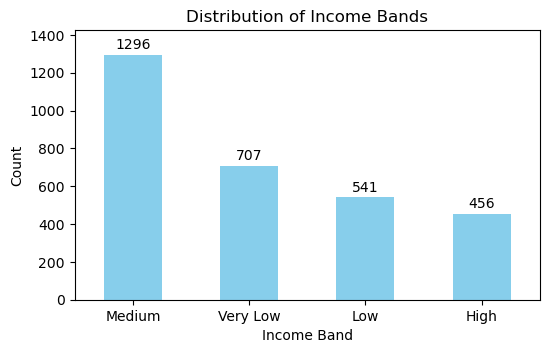

In [11]:
ax = df['Income Band'].value_counts().plot(kind='bar', figsize = (6,3.5), color = 'skyblue')

ax.bar_label(ax.containers[0], padding = 2)

plt.ylim(0, df['Income Band'].value_counts().max() * 1.1)

plt.title('Distribution of Income Bands')
plt.xticks(rotation= 0) 
plt.xlabel('Income Band')
plt.ylabel('Count')

# Clean up the output
plt.show();

#### Univariate (Illustrative) Analysis:

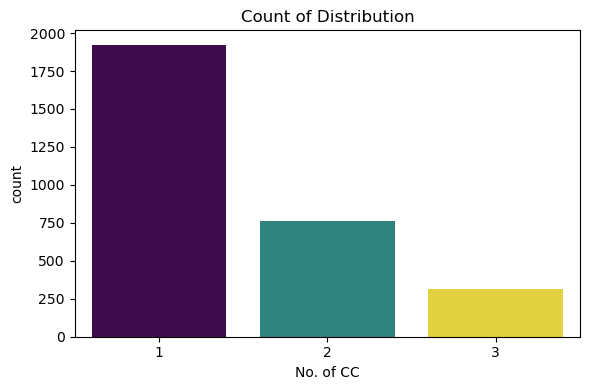

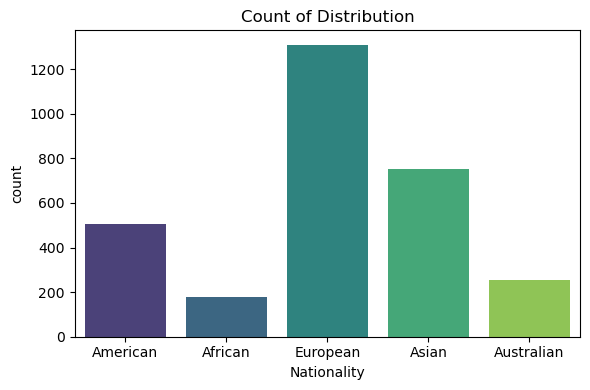

In [12]:
for i, predictor in enumerate(df[["No. of CC", "Nationality"]].columns):
    plt.figure(figsize = (6,4))
    ax = sns.countplot(data = df, x = predictor, hue = predictor, palette = "viridis", legend = False)
    
    plt.title('Count of Distribution')
    plt.tight_layout()
    plt.show();

### Bivariate Analysis:

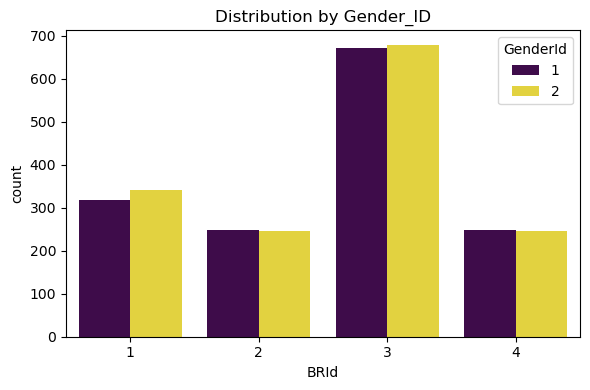

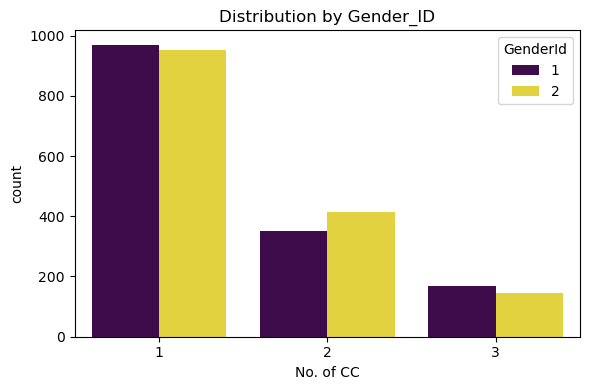

In [13]:
# Gender: 1 - Male, 2 - Female
for i, predictor in enumerate(df[["BRId", "No. of CC"]].columns):
    plt.figure(figsize = (6,4))
    ax = sns.countplot(data = df, x = predictor, hue = 'GenderId', palette = "viridis")
    
    plt.title('Distribution by Gender_ID')
    plt.tight_layout()
    plt.show();

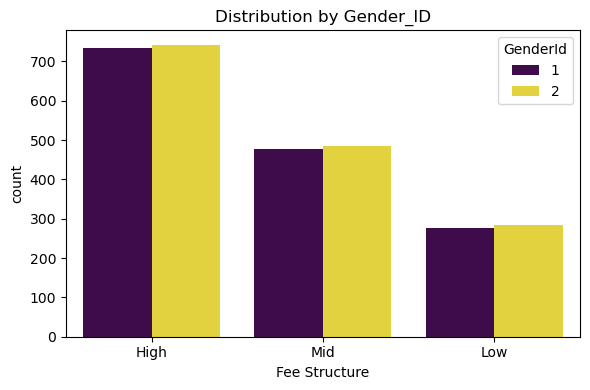

In [14]:
# Gender: 1 - Male, 2 - Female
for i, predictor in enumerate(df[["Fee Structure"]].columns):
    plt.figure(figsize = (6, 4))
    ax = sns.countplot(data = df, x = predictor, hue = 'GenderId', palette = "viridis")
    
    plt.title('Distribution by Gender_ID')
    plt.tight_layout()
    plt.show();

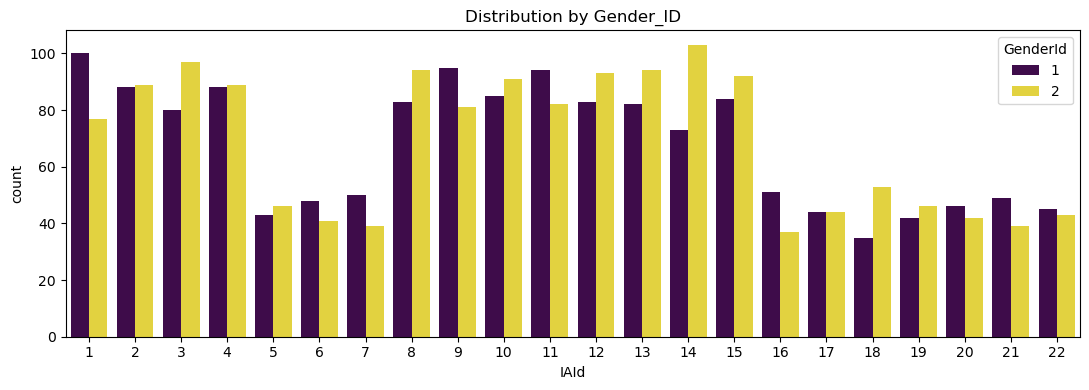

In [15]:
# Gender: 1 - Male, 2 - Female
for i, predictor in enumerate(df[["IAId"]].columns):
    plt.figure(figsize = (11, 4))
    ax = sns.countplot(data = df, x = predictor, hue = 'GenderId', palette = "viridis")
    
    plt.title('Distribution by Gender_ID')
    plt.tight_layout()
    plt.show();

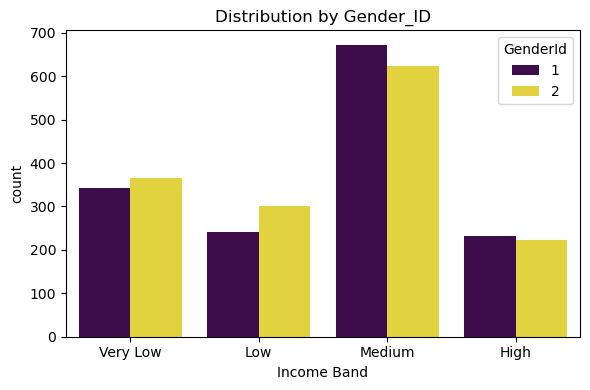

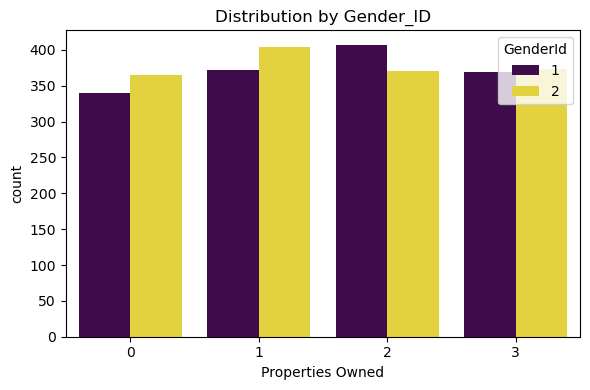

In [16]:
# Gender: 1 - Male 2 - Female
for i, predictor in enumerate(df[["Income Band", "Properties Owned"]].columns):
    plt.figure(figsize = (6,4))
    ax = sns.countplot(data = df, x = predictor, hue = 'GenderId', palette = "viridis")
    
    plt.title('Distribution by Gender_ID')
    plt.tight_layout()
    plt.show();

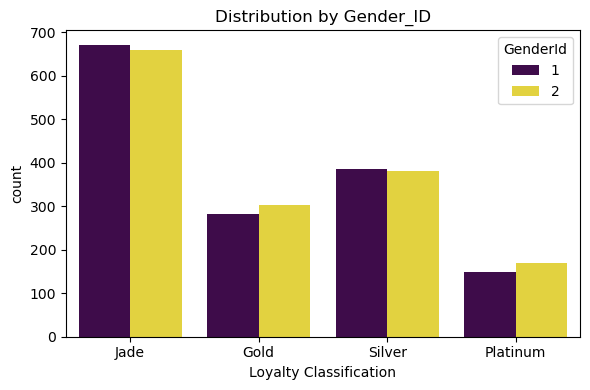

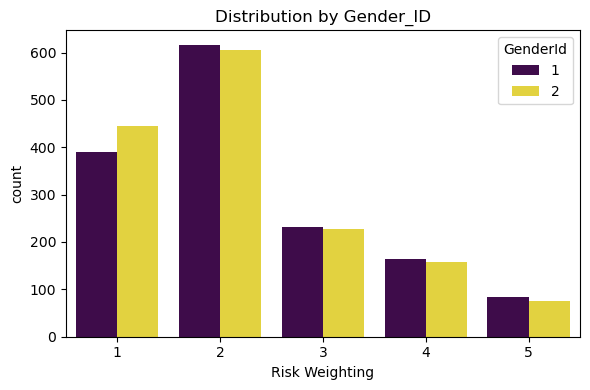

In [17]:
for i, predictor in enumerate(df[["Loyalty Classification", "Risk Weighting"]].columns):
    plt.figure(figsize = (6,4))
    ax = sns.countplot(data = df, x = predictor, hue = 'GenderId', palette = "viridis")
    
    plt.title('Distribution by Gender_ID')
    plt.tight_layout()
    plt.show();

#### Bivariate Analysis: Distributed by 'Nationality'

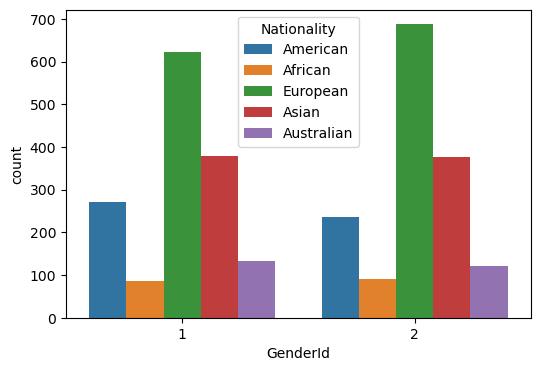

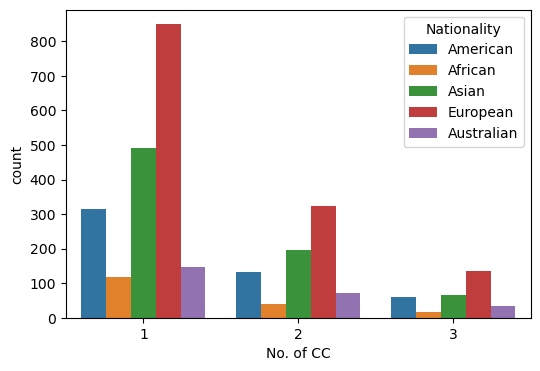

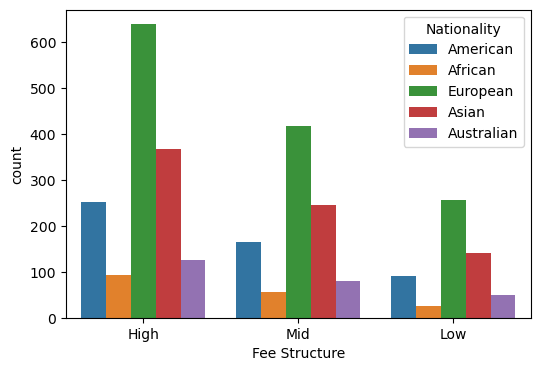

In [18]:
for i, predictor in enumerate(df[["GenderId", "No. of CC", "Fee Structure"]].columns):
    plt.figure(figsize = (6,4))
    sns.countplot(data=df, x = predictor, hue ='Nationality')

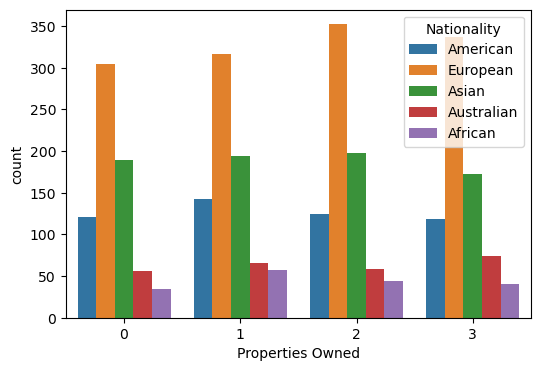

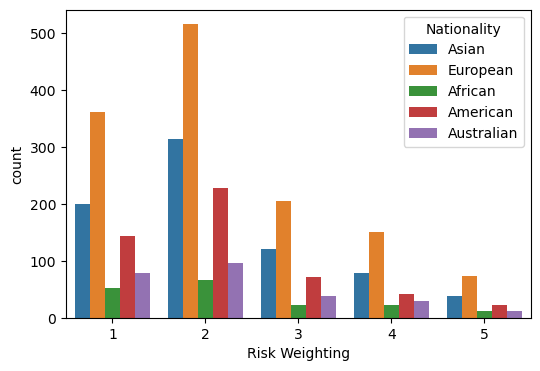

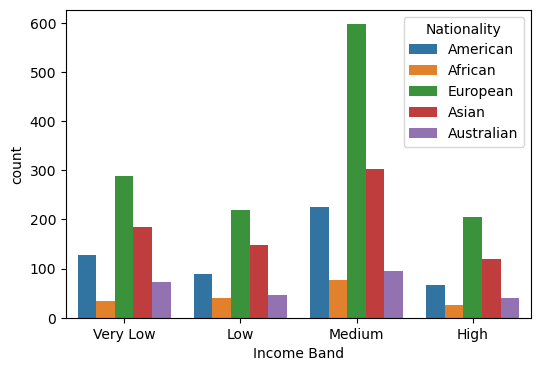

In [19]:
for i, predictor in enumerate(df[["Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(figsize = (6,4))
    sns.countplot(data=df, x = predictor, hue ='Nationality')

#### Histogram Chart

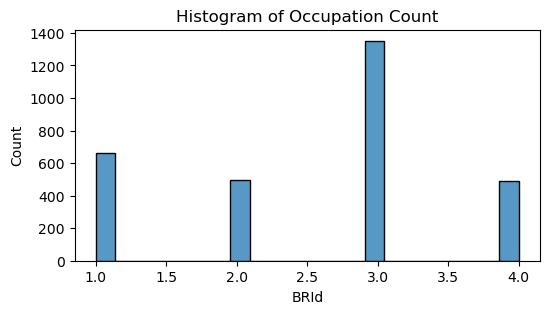

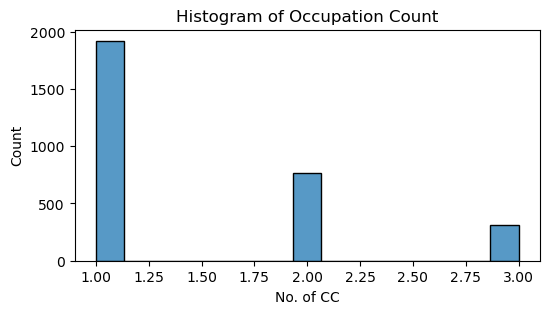

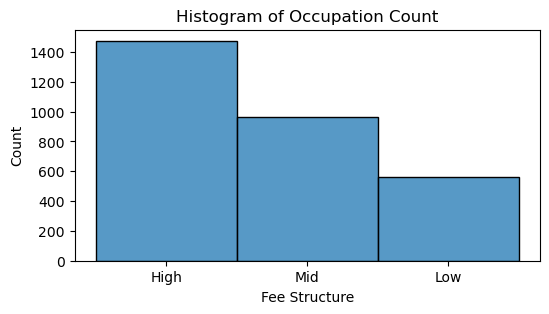

In [20]:
catg_cols = df[["BRId", "No. of CC", "Fee Structure"]].columns

for col in catg_cols:
  if col == "Occupation":
    continue
  plt.figure(figsize=(6,3))
  sns.histplot(df[col])
  plt.title('Histogram of Occupation Count')
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

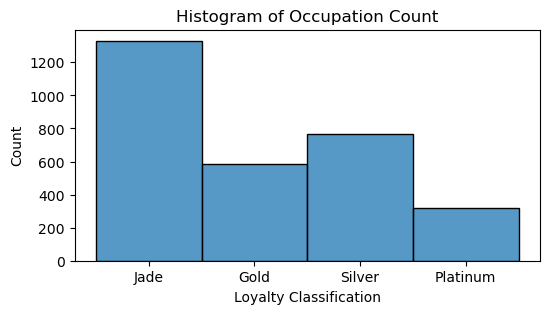

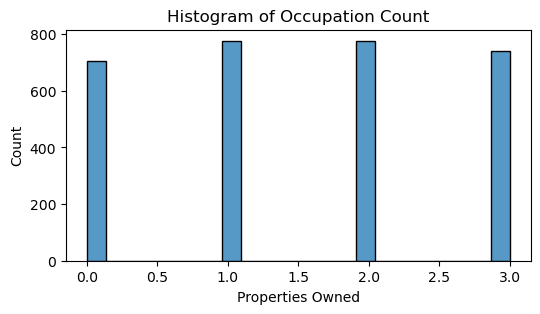

In [21]:
catg_cols = df[["Loyalty Classification", "Properties Owned"]].columns

for col in catg_cols:
  if col == "Occupation":
    continue
  plt.figure(figsize=(6,3))
  sns.histplot(df[col])
  plt.title('Histogram of Occupation Count')
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

#### Numerical Chart Analysis:

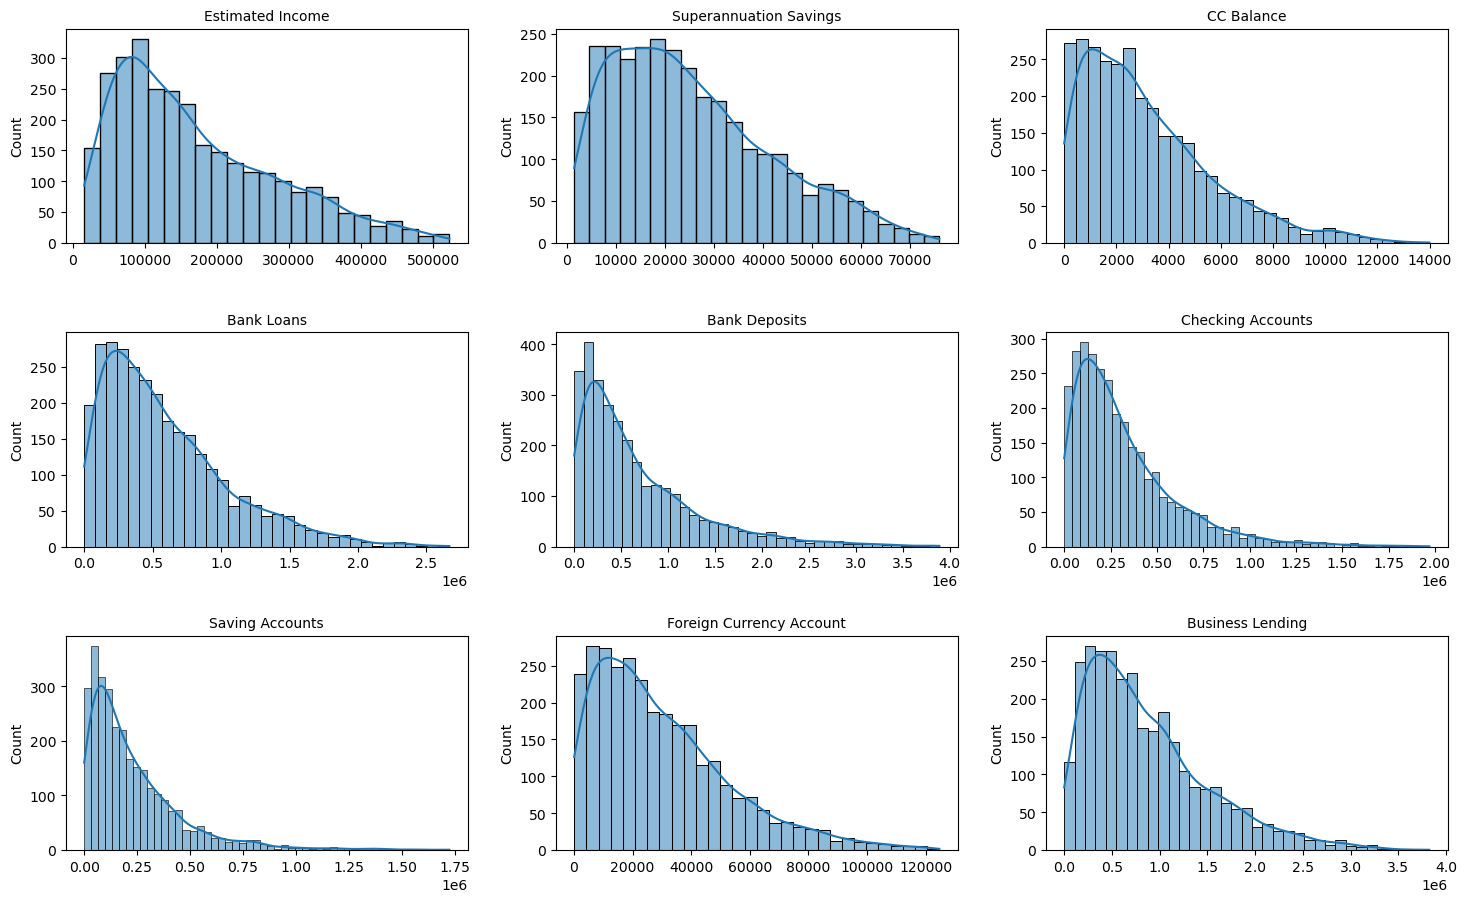

In [22]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'CC Balance', 'Bank Loans', 'Bank Deposits', 
                  'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

plt.figure(figsize=(15, 12)) # Increased height to accommodate 4 rows comfortably

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col, fontsize=10)
    plt.xlabel("") # Optional: removes 'col' name from x-axis to save space

# This line fixes the overlap seen in 333.png
plt.tight_layout(pad=2.0) 

plt.show()

### Heatmaps:

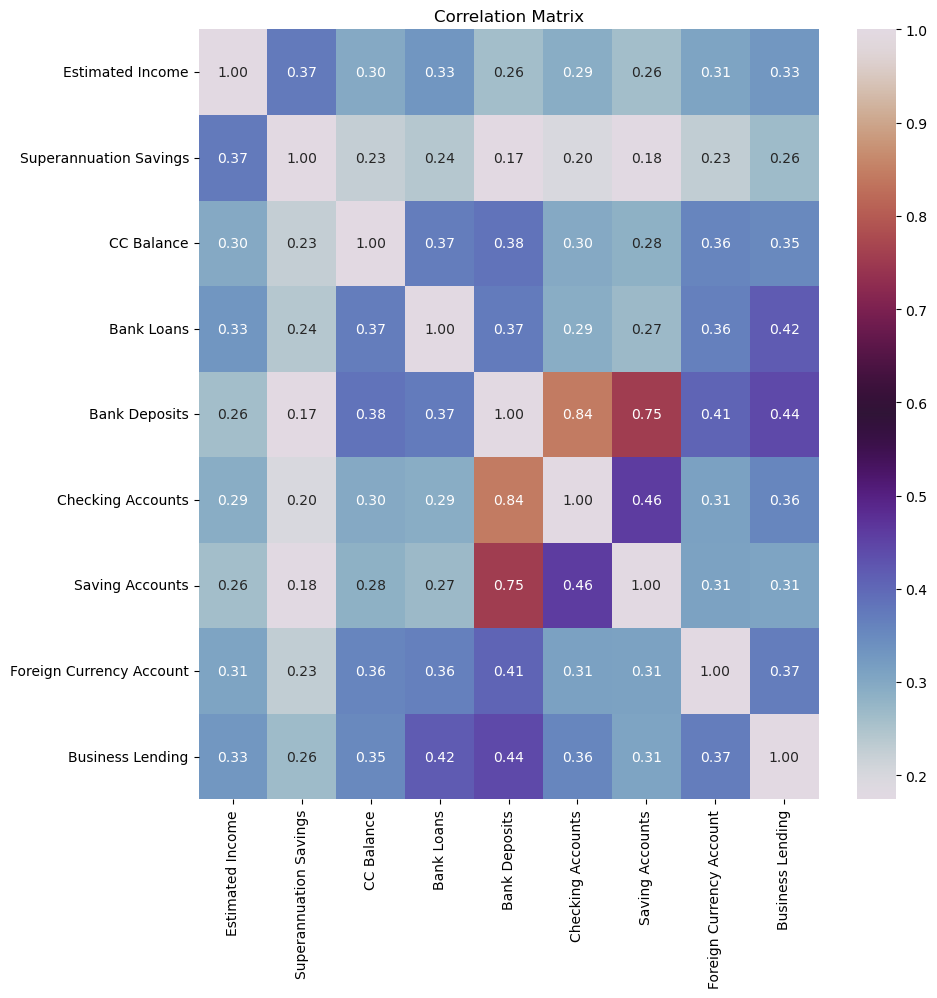

In [27]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'CC Balance', 'Bank Loans', 'Bank Deposits', 
                  'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix, annot=True, cmap ='twilight', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#### Correlation Charts:

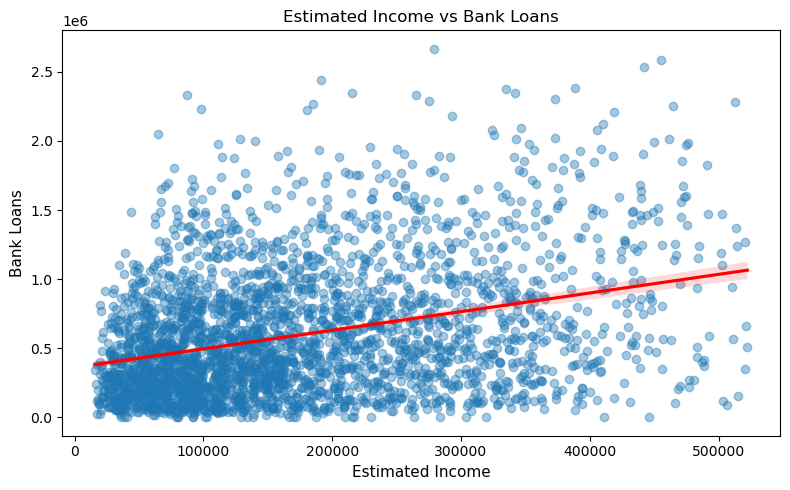

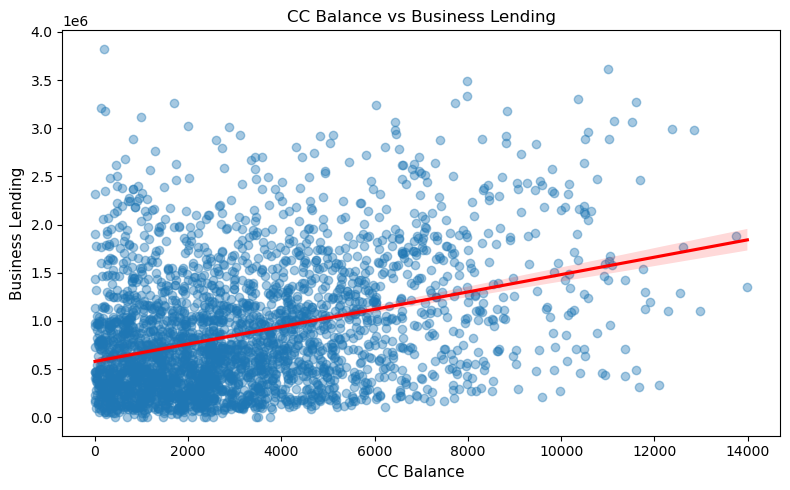

In [24]:
pairs_to_plot = [
    ('Estimated Income', 'Bank Loans'),
    ('CC Balance', 'Business Lending')]

for x_col, y_col in pairs_to_plot:
    plt.figure(figsize=(8, 5))
    sns.regplot(data = df, x = x_col, y = y_col,
                scatter_kws={'alpha': 0.4},     # semi-transparent points
                line_kws={'color': 'red'})    # best-fit line color
    
    plt.title(f'{x_col} vs {y_col}', fontsize = 12)
    plt.xlabel(x_col, fontsize = 11)
    plt.ylabel(y_col, fontsize = 11)
    plt.tight_layout()
    plt.show()

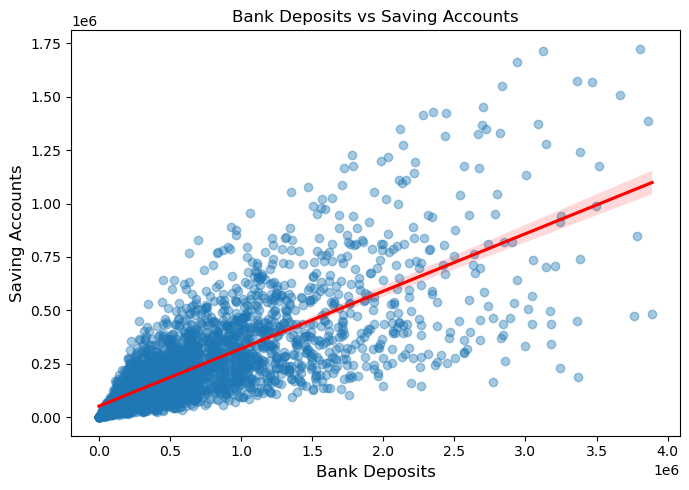

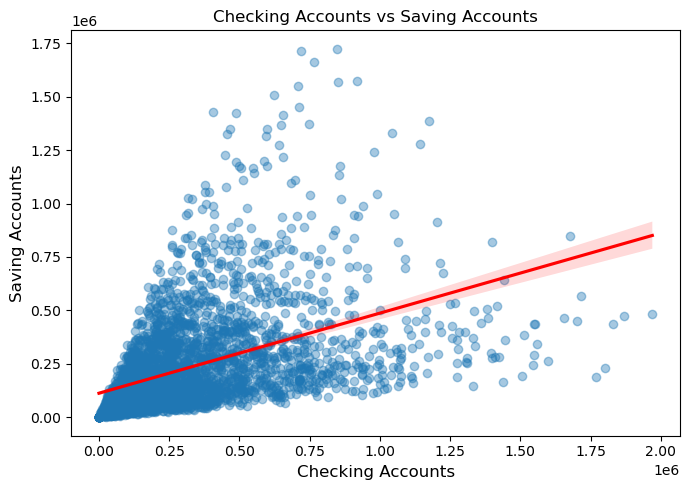

In [25]:
pairs_to_plot = [
    ('Bank Deposits', 'Saving Accounts'),
    ('Checking Accounts', 'Saving Accounts')]

for x_col, y_col in pairs_to_plot:
    plt.figure(figsize = (7, 5))
    sns.regplot(data = df, x =x_col,y =y_col, scatter_kws ={'alpha': 0.4},     # semi-transparent point
                line_kws = {'color': 'red'} )   # best-fit line color

    plt.title(f'{x_col} vs {y_col}', fontsize = 12)
    plt.xlabel(x_col, fontsize = 12)
    plt.ylabel(y_col, fontsize = 12)
    plt.tight_layout()
    plt.show();

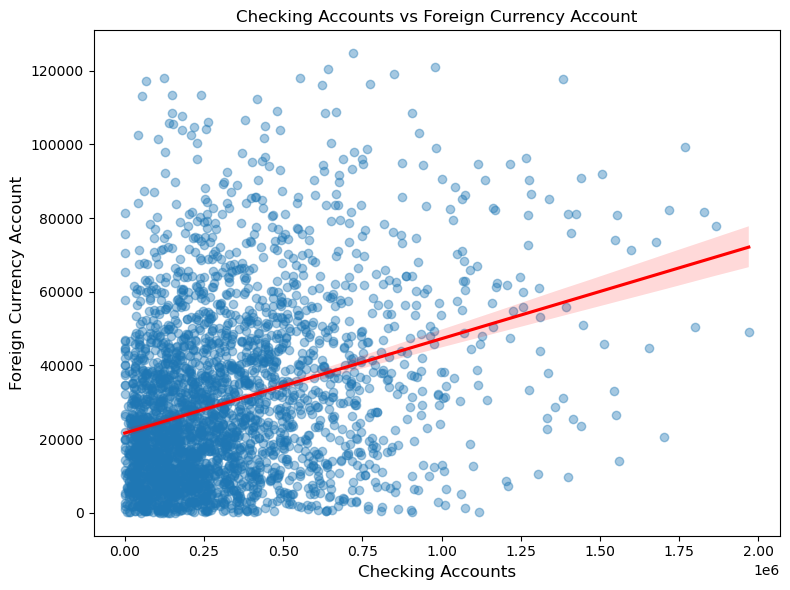

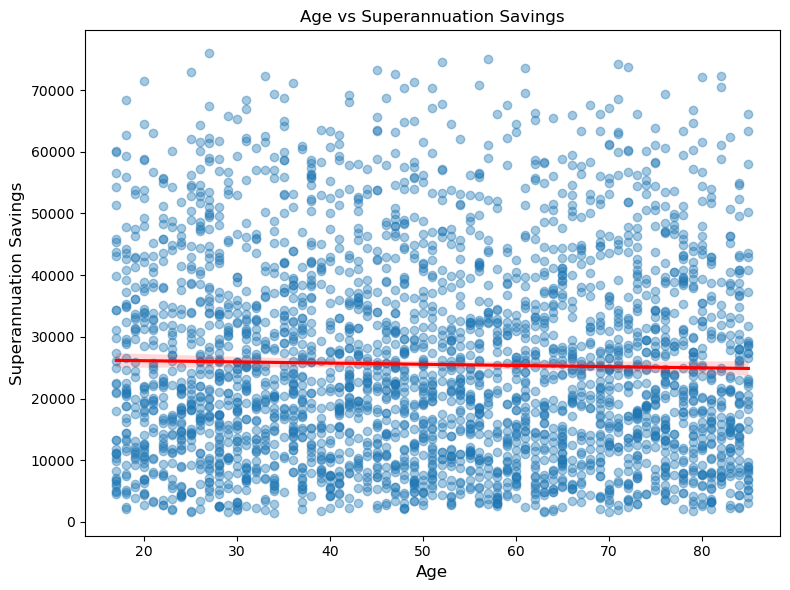

In [26]:
pairs_to_plot = [
    ('Checking Accounts', 'Foreign Currency Account'),
    ('Age', 'Superannuation Savings')]

for x_col, y_col in pairs_to_plot:
    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter_kws={'alpha': 0.4},     # semi-transparent points
        line_kws={'color': 'red'}       # best-fit line color
    )
    plt.title(f'{x_col} vs {y_col}', fontsize = 12)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.tight_layout()
    plt.show()

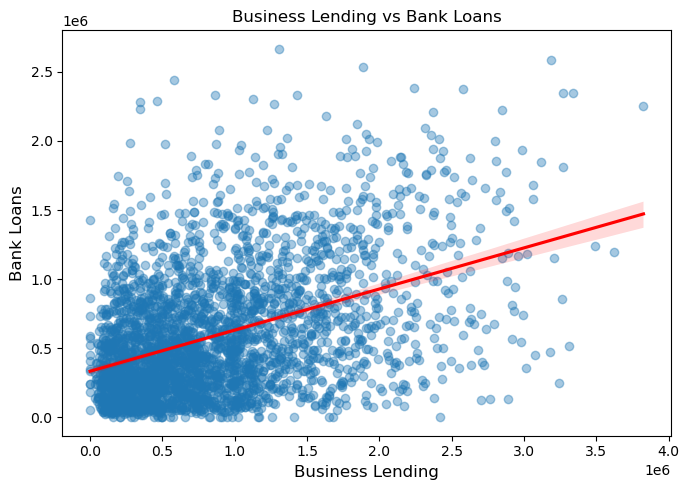

In [28]:
pairs_to_plot = [
    ('Business Lending', 'Bank Loans')]

for x_col, y_col in pairs_to_plot:
    plt.figure(figsize=(7, 5))
    sns.regplot(
        data=df, x =x_col, y = y_col,
        scatter_kws={'alpha': 0.4},     # semi-transparent points
        line_kws={'color': 'red'}       # best-fit line color
    )
    plt.title(f'{x_col} vs {y_col}', fontsize = 12)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.tight_layout()
    plt.show()

#### Insights: Deposits and Savings Behavior

- The high correlation between Bank Deposits and Saving Accounts suggests that these may either measure overlapping financial behavior (e.g., total funds a customer keeps in the bank) or that people who actively deposit funds also tend to maintain or grow savings balances.

#### Income, Age, and Accumulation:

- Moderate correlations of Age and Estimated Income with various balances (Superannuation, Savings, Checking) reflect a common financial lifecycle trend: higher income earners and older individuals often accumulate more savings, retirement funds. They may carry higher credit card balances or loans.

#### Low Correlation with Properties Owned:

- Property ownership may depend on external factors (location, real estate market conditions, inheritance, etc.) that are not captured by these particular banking variables. Hence, we see weaker correlations here.

#### Business vs. Personal Banking

- Business Lending’s moderate link to Bank Loans suggests some customers may have both personal and business debts. However, business lending is relatively uncorrelated with other deposit or property-related metrics, indicating it may serve a distinct subset of customers or needs.
